# Confidence Intervals

Week 2 reported a 95% CI **for the mean** (t-interval and percentile bootstrap) for every variable. For revenue and copies sold that target is a poor choice: the mean is ~24× / ~12× the median, is driven by a few dozen games, and the sampling distribution of the mean converges to normality extremely slowly under such tails — so "n = 1,500 ⇒ CLT ⇒ fine" is not safe.

This notebook (i) chooses estimands that describe a *typical* game (median, geometric mean, trimmed mean), (ii) uses **BCa bootstrap** intervals, and (iii) **tests by simulation** whether the Week 2 interval for the mean actually covers 95% of the time when data look like this.

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sys.path.append(str(Path.cwd().parent))  # project root: import via the src package so src/statistics.py cannot shadow the stdlib module
from src import statistics as rs

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold", "axes.titlesize": 12})
pd.options.display.float_format = "{:,.4g}".format
pd.options.display.width = 140

df = rs.load_robust()
CLS = rs.CLASS_ORDER
PAL = rs.CLASS_COLORS
print(f"n = {len(df):,}  |  columns = {df.shape[1]}")

n = 1,500  |  columns = 20


In [2]:
N_BOOT = 9999
VARS = {
    "revenue": df.revenue.astype(float),
    "copiesSold": df.copiesSold.astype(float),
    "avgPlaytime": df.avgPlaytime.where(df.avgPlaytime > 0),
    "price (paid)": df.price.where(df.price > 0),
    "reviewScore (scored)": df.reviewScore_clean,
}
trim10 = lambda v, axis=-1: stats.trim_mean(v, .10, axis=axis)
gmean = lambda v, axis=-1: np.exp(np.mean(np.log(v), axis=axis))

## 1. Five estimands, several interval methods

In [3]:
rows = []
for name, s in VARS.items():
    v = s.dropna().values
    pos = (v > 0).all()
    # (a) Week 2 style: mean with t-interval
    m, se = v.mean(), stats.sem(v)
    lo, hi = stats.t.interval(.95, len(v) - 1, loc=m, scale=se)
    rows.append([name, "mean", "t-interval (Week 2)", m, lo, hi])
    # (b) mean, BCa
    e, lo, hi = rs.bca_ci(v, np.mean, N_BOOT); rows.append([name, "mean", "BCa bootstrap", e, lo, hi])
    # (c) 10% trimmed mean, BCa
    e, lo, hi = rs.bca_ci(v, trim10, N_BOOT); rows.append([name, "10% trimmed mean", "BCa bootstrap", e, lo, hi])
    # (d) median, BCa
    e, lo, hi = rs.bca_ci(v, np.median, N_BOOT); rows.append([name, "median", "BCa bootstrap", e, lo, hi])
    # (e) geometric mean
    if pos:
        e, lo, hi = rs.t_ci_on_log(v); rows.append([name, "geometric mean", "t on log scale, back-transformed", e, lo, hi])
        e, lo, hi = rs.bca_ci(v, gmean, N_BOOT); rows.append([name, "geometric mean", "BCa bootstrap", e, lo, hi])

ci = pd.DataFrame(rows, columns=["variable", "statistic", "method", "estimate", "ci_low", "ci_high"])
ci["ci_width"] = ci.ci_high - ci.ci_low
ci["relative_width"] = ci.ci_width / ci.estimate
rs.save_table(ci, "ci_robust.csv")
ci[ci.variable == "revenue"]

,variable,statistic,method,estimate,ci_low,ci_high,ci_width,relative_width
0,revenue,mean,t-interval (Week 2),2.632e+06,1.224e+06,4.041e+06,2.817e+06,1.07
1,revenue,mean,BCa bootstrap,2.632e+06,1.689e+06,5.006e+06,3.318e+06,1.26
2,revenue,10% trimmed mean,BCa bootstrap,2.788e+05,2.445e+05,3.205e+05,7.602e+04,0.2727
3,revenue,median,BCa bootstrap,1.091e+05,9.885e+04,1.203e+05,2.145e+04,0.1967
4,revenue,geometric mean,"t on log scale, back-transformed",1.717e+05,1.574e+05,1.873e+05,2.996e+04,0.1745
5,revenue,geometric mean,BCa bootstrap,1.717e+05,1.582e+05,1.872e+05,2.905e+04,0.1692


In [4]:
pd.options.display.float_format = "{:,.4g}".format
ci.pivot_table(index=["variable", "statistic", "method"], values=["estimate", "ci_low", "ci_high", "relative_width"], sort=False)

estimate    ci_low   ci_high  relative_width
variable             statistic        method                                                                        
revenue              mean             t-interval (Week 2)              2.632e+06 1.224e+06 4.041e+06            1.07
                                      BCa bootstrap                    2.632e+06 1.689e+06 5.006e+06            1.26
                     10% trimmed mean BCa bootstrap                    2.788e+05 2.445e+05 3.205e+05          0.2727
                     median           BCa bootstrap                    1.091e+05 9.885e+04 1.203e+05          0.1967
                     geometric mean   t on log scale, back-transformed 1.717e+05 1.574e+05 1.873e+05          0.1745
                                      BCa bootstrap                    1.717e+05 1.582e+05 1.872e+05          0.1692
copiesSold           mean             t-interval (Week 2)              1.415e+05 8.411e+04 1.989e+05           0.811
                                      BCa bootstrap                    1.415e+05 9.998e+04 2.242e+05          0.8778
                     10% trimmed mean BCa bootstrap                    2.262e+04 2.019e+04 2.547e+04          0.2336
                     median           BCa bootstrap                    1.193e+04 1.054e+04 1.313e+04          0.2178
                     geometric mean   t on log scale, back-transformed 1.543e+04 1.423e+04 1.674e+04          0.1629
                                      BCa bootstrap                    1.543e+04 1.424e+04 1.673e+04          0.1612
avgPlaytime          mean             t-interval (Week 2)                  12.57     11.48     13.66          0.1737
                                      BCa bootstrap                        12.57     11.61     13.84          0.1775
                     10% trimmed mean BCa bootstrap                        8.558     8.077      9.08          0.1173
                     median           BCa bootstrap                        6.763     6.473     7.254          0.1154
                     geometric mean   t on log scale, back-transformed     7.098     6.746     7.469          0.1018
                                      BCa bootstrap                        7.098     6.751     7.468           0.101
price (paid)         mean             t-interval (Week 2)                  18.57     17.93     19.21         0.06878
                                      BCa bootstrap                        18.57     17.96     19.23         0.06847
                     10% trimmed mean BCa bootstrap                        16.77     16.24     17.32         0.06479
                     median           BCa bootstrap                        14.99     14.99     15.99         0.06671
                     geometric mean   t on log scale, back-transformed     15.25     14.74     15.77          0.0672
                                      BCa bootstrap                        15.25     14.75     15.77         0.06704
reviewScore (scored) mean             t-interval (Week 2)                  81.59     80.86     82.32         0.01788
                                      BCa bootstrap                        81.59     80.85     82.29         0.01768
                     10% trimmed mean BCa bootstrap                        83.43     82.71     84.12         0.01689
                     median           BCa bootstrap                           85       NaN       NaN             NaN
                     geometric mean   t on log scale, back-transformed     80.06     79.18     80.95         0.02213
                                      BCa bootstrap                        80.06     79.14      80.9           0.022

**Reading the revenue rows.** The mean's interval is roughly ±50–60% of its own value, sits far above the median's, and the t and BCa versions disagree noticeably (the sampling distribution is right-skewed); the median's and geometric mean's intervals are each only about ±9–10% wide. In relative terms the median's and geometric mean's intervals are about 5–6× narrower than the mean's (≈ 17–20% vs ≈ 107–126% of the estimate), and they describe a quantity that real games actually have.

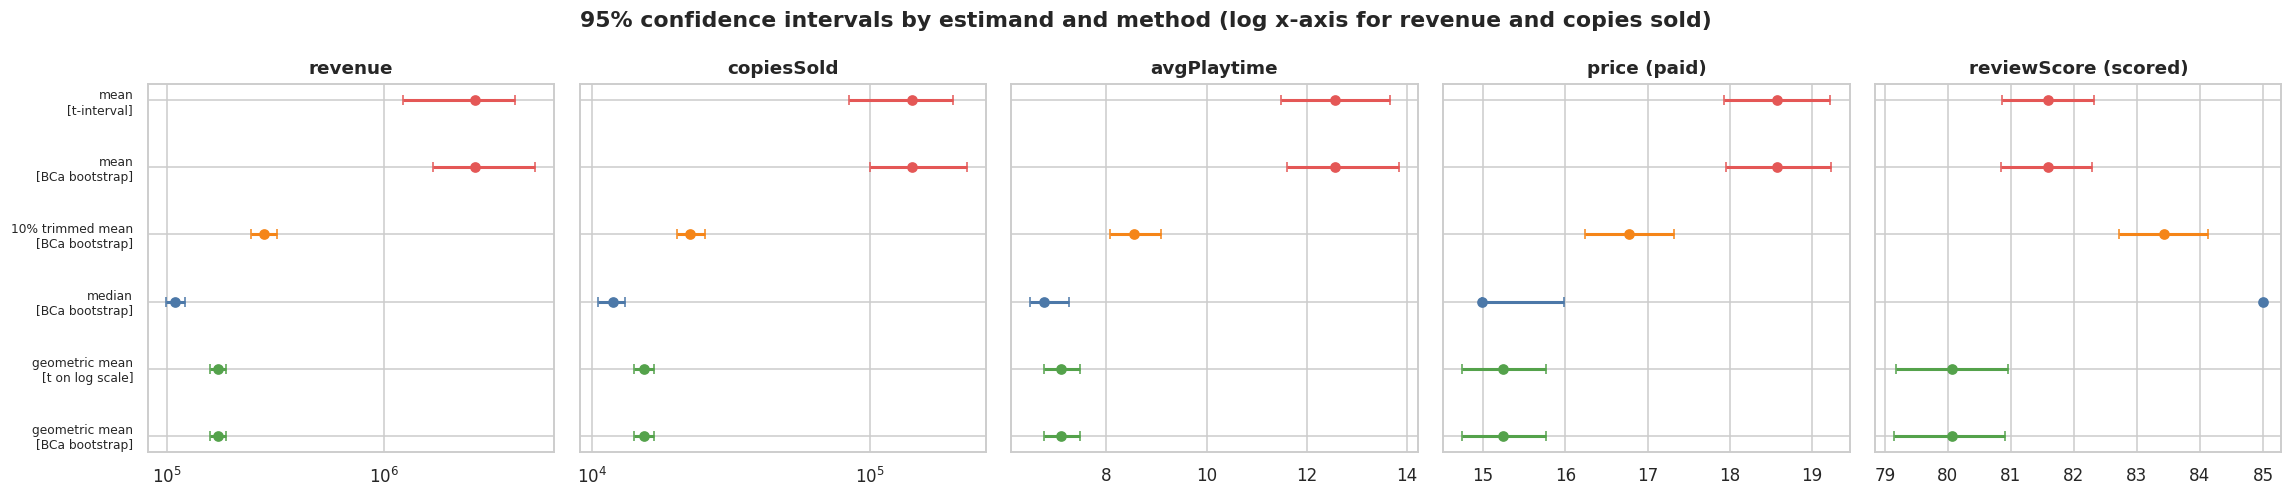

In [5]:
fig, axes = plt.subplots(1, 5, figsize=(21, 4.6))
style = {"mean": "#E45756", "10% trimmed mean": "#F58518", "median": "#4C78A8", "geometric mean": "#54A24B"}
for ax, name in zip(axes, VARS):
    g = ci[(ci.variable == name)].reset_index(drop=True)
    for k, r_ in g.iterrows():
        ax.errorbar(r_.estimate, k, xerr=[[r_.estimate - r_.ci_low], [r_.ci_high - r_.estimate]], fmt="o", color=style[r_.statistic], capsize=3, lw=2)
    ax.set_yticks(range(len(g))); ax.set_yticklabels([f"{a}\n[{b.split(',')[0].split(' (')[0]}]" for a, b in zip(g.statistic, g.method)] if ax is axes[0] else [], fontsize=8)
    ax.invert_yaxis(); ax.set_title(name)
    if name in ("revenue", "copiesSold"):
        ax.set_xscale("log")
fig.suptitle("95% confidence intervals by estimand and method (log x-axis for revenue and copies sold)", fontweight="bold")
fig.tight_layout(); rs.save_fig(fig, "r06_ci_forest_by_variable.png"); plt.show()

## 2. Does the Week 2 interval for the mean actually cover 95%?

**Simulation design.** Take the fitted truncated-lognormal model of revenue from notebook 05 (which passes a valid goodness-of-fit test), draw 2,000 synthetic samples of n = 1,500, build 95% intervals for the mean, median and geometric mean in each, and record how often they contain the **known true** parameter. If the procedure is sound, coverage ≈ 95%.

In [6]:
from scipy.stats import norm, truncnorm

x = df.revenue.values
ln_fit = rs.fit_candidates(x, {"Lognormal": stats.lognorm}, truncate_at=x.min()).iloc[0]
s_, _, scale_ = ln_fit.params
mu_ = np.log(scale_); a_ = (np.log(x.min()) - mu_) / s_             # Z = ln X ~ N(mu, s^2) truncated at ln(xmin)

true_mean = np.exp(mu_ + s_ ** 2 / 2) * norm.sf(a_ - s_) / norm.sf(a_)
true_median = np.exp(truncnorm.median(a_, np.inf, loc=mu_, scale=s_))
true_gmean = np.exp(truncnorm.mean(a_, np.inf, loc=mu_, scale=s_))
print(f"Fitted model: mu = {mu_:.3f}, sigma = {s_:.3f}, truncation at ln(${x.min():,.0f})")
print(f"True parameters -> mean ${true_mean:,.0f} | median ${true_median:,.0f} | geometric mean ${true_gmean:,.0f}")
print(f"(sample values: mean ${x.mean():,.0f} | median ${np.median(x):,.0f} | geometric mean ${np.exp(np.log(x).mean()):,.0f})")

Fitted model: mu = 8.109, sigma = 3.363, truncation at ln($20,674)
True parameters -> mean $3,226,083 | median $113,798 | geometric mean $171,715
(sample values: mean $2,632,382 | median $109,053 | geometric mean $171,715)


In [7]:
rng = np.random.default_rng(rs.RNG_SEED)
n, R = 1500, 2000
f0 = norm.cdf(a_)
hit = {"mean: t-interval": 0, "mean: percentile bootstrap": 0, "median: rank-based": 0, "geometric mean: t on log scale": 0}
B_SIM, R_BOOT = 500, 1000                       # bootstrap coverage is checked on the first B_SIM replications
width_mean, width_med = [], []
lo_rank = int(stats.binom.ppf(.025, n, .5)); hi_rank = n - lo_rank - 1
n_boot_checked = 0

for r in range(R):
    z = norm.ppf(rng.uniform(f0, 1, n)); xs = np.exp(mu_ + s_ * z)
    m, se = xs.mean(), stats.sem(xs)
    lo, hi = stats.t.interval(.95, n - 1, loc=m, scale=se); hit["mean: t-interval"] += lo <= true_mean <= hi; width_mean.append(hi - lo)
    if r < B_SIM:
        bm = xs[rng.integers(0, n, (R_BOOT, n))].mean(1); lo, hi = np.percentile(bm, [2.5, 97.5])
        hit["mean: percentile bootstrap"] += lo <= true_mean <= hi; n_boot_checked += 1
    srt = np.sort(xs); hit["median: rank-based"] += srt[lo_rank] <= true_median <= srt[hi_rank]
    lx = np.log(xs); lo, hi = stats.t.interval(.95, n - 1, loc=lx.mean(), scale=stats.sem(lx))
    hit["geometric mean: t on log scale"] += np.exp(lo) <= true_gmean <= np.exp(hi)

den = {k: (n_boot_checked if "bootstrap" in k else R) for k in hit}
cov = pd.DataFrame({"replications": den, "coverage": {k: hit[k] / den[k] for k in hit}})
cov["MC std. error"] = np.sqrt(cov.coverage * (1 - cov.coverage) / cov.replications)
cov["nominal"] = .95
rs.save_table(cov.reset_index().rename(columns={"index": "procedure"}), "ci_coverage_simulation.csv")
cov

,replications,coverage,MC std. error,nominal
mean: t-interval,2000,0.5845,0.01102,0.95
mean: percentile bootstrap,500,0.586,0.02203,0.95
median: rank-based,2000,0.9465,0.005032,0.95
geometric mean: t on log scale,2000,0.946,0.005054,0.95


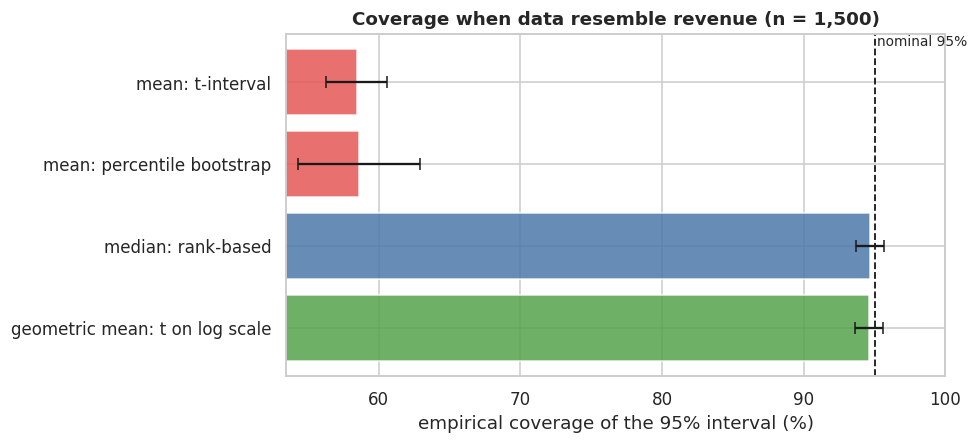

In [8]:
fig, ax = plt.subplots(figsize=(9, 4.2))
cols = ["#E45756", "#E45756", "#4C78A8", "#54A24B"]
ax.barh(cov.index, cov.coverage * 100, xerr=1.96 * cov["MC std. error"] * 100, color=cols, alpha=.85, capsize=4)
ax.axvline(95, color="k", ls="--", lw=1.2); ax.text(95.2, -.45, "nominal 95%", fontsize=9)
ax.set_xlim(min(70, cov.coverage.min() * 100 - 5), 100); ax.invert_yaxis()
ax.set_xlabel("empirical coverage of the 95% interval (%)"); ax.set_title("Coverage when data resemble revenue (n = 1,500)")
fig.tight_layout(); rs.save_fig(fig, "r06_ci_coverage_simulation.png"); plt.show()

**Result.** The Week 2 interval for the mean revenue covers the true value only ~58% of the time under the fitted lognormal — nowhere near 95% — and the percentile bootstrap does not rescue it (the Weibull check below gives ~76%; still far short). The rank-based median interval and the log-scale geometric-mean interval both hit the nominal level.

**Caveat / robustness check.** The true mean of a heavy-tailed model depends on the part of the tail *beyond* anything observed, which no goodness-of-fit test can pin down. The truncated Weibull also passes the bootstrap KS test (p = 0.16), has a different extreme tail, and gives a different "true" mean. The check below repeats the mean-interval coverage under that alternative.

In [9]:
from scipy.special import gammaincc, gamma as gfun
wb = rs.fit_candidates(x, {"Weibull": stats.weibull_min}, truncate_at=x.min()).iloc[0]
c_, _, sc_ = wb.params
t_ = (x.min() / sc_) ** c_
wb_true_mean = sc_ * gfun(1 + 1 / c_) * gammaincc(1 + 1 / c_, t_) / np.exp(-t_)
wb_true_med = stats.weibull_min.ppf(stats.weibull_min.cdf(x.min() * (1 - 1e-9), c_, 0, sc_) + .5 * stats.weibull_min.sf(x.min() * (1 - 1e-9), c_, 0, sc_), c_, 0, sc_)
f0w = stats.weibull_min.cdf(x.min() * (1 - 1e-9), c_, 0, sc_)
rng2 = np.random.default_rng(rs.RNG_SEED + 1)
hit_m = hit_md = 0
for r in range(R):
    xs = stats.weibull_min.ppf(rng2.uniform(f0w, 1, n), c_, 0, sc_)
    m, se = xs.mean(), stats.sem(xs); lo, hi = stats.t.interval(.95, n - 1, loc=m, scale=se); hit_m += lo <= wb_true_mean <= hi
    srt = np.sort(xs); hit_md += srt[lo_rank] <= wb_true_med <= srt[hi_rank]
print(f"Truncated Weibull (shape {c_:.3f}): true mean ${wb_true_mean:,.0f}, true median ${wb_true_med:,.0f}")
print(f"Coverage of the Week 2 t-interval for the mean : {hit_m / R:.1%}")
print(f"Coverage of the rank-based interval for median : {hit_md / R:.1%}")

Truncated Weibull (shape 0.135): true mean $2,291,278, true median $112,437
Coverage of the Week 2 t-interval for the mean : 75.6%
Coverage of the rank-based interval for median : 93.8%


## 3. Group-level intervals: median revenue and copies by publisher class

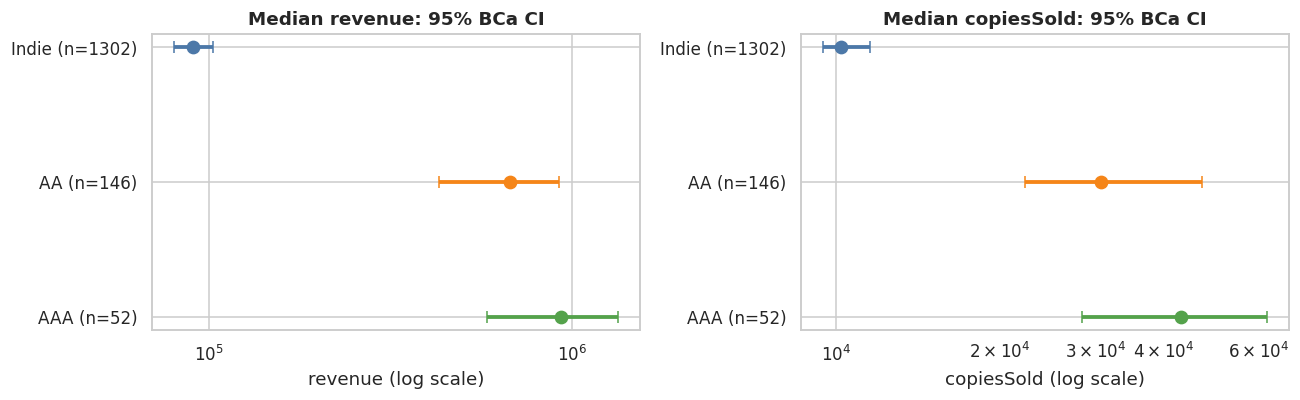

,variable,publisherClass,n,median,ci_low,ci_high
0,revenue,Indie,1302,9.077e+04,8.032e+04,1.03e+05
1,revenue,AA,146,6.722e+05,4.288e+05,9.169e+05
2,revenue,AAA,52,9.289e+05,5.832e+05,1.335e+06
3,copiesSold,Indie,1302,1.021e+04,"9,466",1.155e+04
4,copiesSold,AA,146,3.068e+04,2.22e+04,4.715e+04
5,copiesSold,AAA,52,4.316e+04,2.837e+04,6.209e+04


In [10]:
rows = []
for var in ["revenue", "copiesSold"]:
    for c in CLS:
        v = df.loc[df.publisherClass == c, var].astype(float).values
        e, lo, hi = rs.bca_ci(v, np.median, N_BOOT)
        rows.append([var, c, len(v), e, lo, hi])
by_class = pd.DataFrame(rows, columns=["variable", "publisherClass", "n", "median", "ci_low", "ci_high"])
rs.save_table(by_class, "ci_median_by_class.csv")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for ax, var in zip(axes, ["revenue", "copiesSold"]):
    g = by_class[by_class.variable == var].reset_index(drop=True)
    for k, r_ in g.iterrows():
        ax.errorbar(r_["median"], k, xerr=[[r_["median"] - r_.ci_low], [r_.ci_high - r_["median"]]], fmt="o", color=PAL[r_.publisherClass], capsize=4, lw=2.5, ms=8)
    ax.set_yticks(range(3)); ax.set_yticklabels([f"{c} (n={n_})" for c, n_ in zip(g.publisherClass, g.n)]); ax.invert_yaxis()
    ax.set_xscale("log"); ax.set_title(f"Median {var}: 95% BCa CI"); ax.set_xlabel(var + " (log scale)")
fig.tight_layout(); rs.save_fig(fig, "r06_median_ci_by_class.png"); plt.show()
by_class